# **Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Libraries**

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Define Project Paths**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

SAVE_DIR = os.path.join(PROJECT_DIR, "saved_objects")

# **Load the Saved Objects**

In [4]:
with open(os.path.join(SAVE_DIR, "train_df.pkl"), "rb") as f:
    train_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "val_df.pkl"), "rb") as f:
    val_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "test_df.pkl"), "rb") as f:
    test_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

with open(os.path.join(SAVE_DIR, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)

# **Verify the Data**

In [5]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head()

(7010, 10)
(1502, 10)
(1503, 10)


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,disease,label
4357,HAM_0000946,ISIC_0031775,nv,follow_up,60.0,male,trunk,dataset/ham10000_images_part_2/ISIC_0031775.jpg,Melanocytic Nevi,5
1751,HAM_0006097,ISIC_0027306,mel,histo,60.0,male,chest,dataset/HAM10000_images_part_1/ISIC_0027306.jpg,Melanoma,4
9527,HAM_0004348,ISIC_0033895,nv,consensus,40.0,female,unknown,dataset/ham10000_images_part_2/ISIC_0033895.jpg,Melanocytic Nevi,5
8311,HAM_0006608,ISIC_0025491,nv,histo,60.0,male,back,dataset/HAM10000_images_part_1/ISIC_0025491.jpg,Melanocytic Nevi,5
1214,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,dataset/ham10000_images_part_2/ISIC_0031023.jpg,Melanoma,4


# **Verify the image folder**s

In [6]:
import os

print(os.getcwd())

/content


In [7]:
!ls /content

drive  sample_data


In [16]:
!ls /content/dataset

ls: cannot access '/content/dataset': No such file or directory


In [18]:
!mkdir -p dataset

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p dataset

!unzip -q dataset/skin-cancer-mnist-ham10000.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:07<00:00, 82.4MB/s]



In [19]:
!ls dataset

ham10000_images_part_1	HAM10000_metadata.csv  hmnist_8_8_RGB.csv
HAM10000_images_part_1	hmnist_28_28_L.csv     skin-cancer-mnist-ham10000.zip
ham10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_2	hmnist_8_8_L.csv


# **Verify all image paths**

In [21]:
import os

print("Train:", train_df["path"].apply(os.path.exists).sum(), "/", len(train_df))
print("Validation:", val_df["path"].apply(os.path.exists).sum(), "/", len(val_df))
print("Test:", test_df["path"].apply(os.path.exists).sum(), "/", len(test_df))

Train: 7010 / 7010
Validation: 1502 / 1502
Test: 1503 / 1503


# **Move the dataset to Google Drive**

In [22]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"
os.makedirs(PROJECT_DIR, exist_ok=True)

shutil.copytree(
    "/content/dataset",
    os.path.join(PROJECT_DIR, "dataset"),
    dirs_exist_ok=True
)

print("Dataset copied to Google Drive!")

Dataset copied to Google Drive!


In [23]:
DATASET_DIR = "/content/drive/MyDrive/AI-TeleTriage-System/dataset"

# **Copy Dataset to Google Drive (One Time Only)**

In [27]:
#Create Project Folders
import os

PROJECT_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
SAVE_DIR = os.path.join(PROJECT_DIR, "saved_objects")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [28]:
#Copy Dataset
import shutil

shutil.copytree(
    "/content/dataset",
    DATASET_DIR,
    dirs_exist_ok=True
)

print("Dataset copied successfully!")

Dataset copied successfully!


In [29]:
#Verify
!ls "/content/drive/MyDrive/AI-TeleTriage-System/dataset"

ham10000_images_part_1	HAM10000_metadata.csv  hmnist_8_8_RGB.csv
HAM10000_images_part_1	hmnist_28_28_L.csv     skin-cancer-mnist-ham10000.zip
ham10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_2	hmnist_8_8_L.csv


In [30]:
#Update the Image Paths
import os

BASE_PATH = "/content/drive/MyDrive/AI-TeleTriage-System"

for df in [train_df, val_df, test_df]:
    df["path"] = df["path"].apply(
        lambda x: os.path.join(BASE_PATH, x)
    )

print(train_df["path"].head())

4357    /content/drive/MyDrive/AI-TeleTriage-System/da...
1751    /content/drive/MyDrive/AI-TeleTriage-System/da...
9527    /content/drive/MyDrive/AI-TeleTriage-System/da...
8311    /content/drive/MyDrive/AI-TeleTriage-System/da...
1214    /content/drive/MyDrive/AI-TeleTriage-System/da...
Name: path, dtype: object


In [31]:
#Save the Updated DataFrames
import pickle

with open(os.path.join(SAVE_DIR, "train_df.pkl"), "wb") as f:
    pickle.dump(train_df, f)

with open(os.path.join(SAVE_DIR, "val_df.pkl"), "wb") as f:
    pickle.dump(val_df, f)

with open(os.path.join(SAVE_DIR, "test_df.pkl"), "wb") as f:
    pickle.dump(test_df, f)

print("Updated DataFrames saved successfully!")

Updated DataFrames saved successfully!


# **Create ImageDataGenerator**

🎯 What is ImageDataGenerator?

A CNN doesn't read a DataFrame directly. It learns from batches of images.

ImageDataGenerator:

Reads images from disk.
Resizes them.
Normalizes pixel values.
Optionally performs data augmentation (random transformations).

Instead of loading all 10,015 images into RAM, it loads only one batch at a time.

Why do we use data augmentation?

Your dataset is highly imbalanced:
| Disease | Images |
| ------- | -----: |
| nv      |   6705 |
| df      |    115 |

If the model always sees the same 115 dermatofibroma images, it can overfit.

Data augmentation creates slightly different versions of the training images, helping the model generalize better.

# **Define Image Size**

In [32]:
#We'll use 224 × 224 because it's the standard input size for many CNNs (e.g., ResNet50, DenseNet121) and works well for custom CNNs too.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# **Create the Generators**

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.15,

    width_shift_range=0.10,
    height_shift_range=0.10,

    shear_range=0.10,

    horizontal_flip=True,

    fill_mode="nearest"
)

# Validation & Test generators (no augmentation)
valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

***rescale=1./255<br>***
Converts pixel values from 0–255 to 0–1. Neural networks train more efficiently on normalized data.


***rotation_range=20<br>***
Randomly rotates images up to ±20°.

Helps the model recognize lesions even if the camera angle changes.

***zoom_range=0.15***<br>
Randomly zooms in or out by up to 15%.

***width_shift_range=0.10<br>***
***height_shift_range=0.10<br>***
Randomly shifts the image horizontally or vertically by up to 10%.

***shear_range=0.10***<br>
Applies a slight shear transformation to improve robustness.

***horizontal_flip=True***<br>
Flips images left-to-right.

For dermoscopic images, this is generally acceptable because the diagnosis doesn't depend on left/right orientation.

***fill_mode="nearest"***<br>
Fills any empty pixels created by transformations using the nearest pixel values.

<br>

**Why don't we augment validation and test images?**

Validation and test sets should represent real, unseen data.

If we augment them, the evaluation no longer reflects real-world performance.

That's why only the training generator uses augmentation.

# **Create the Image Generators**

🎯What is a Generator?

Imagine you have 10,015 images.

Loading all of them into RAM at once is inefficient. Instead, TensorFlow uses a generator, which:

Reads images batch by batch (e.g., 32 images at a time).
Applies preprocessing and augmentation on the fly.
Feeds those batches directly to the CNN during training.

Think of it like a conveyor belt in a factory—only the current batch is processed, not the entire dataset.

# **Create the Training Generator**

In [34]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 7010 validated image filenames belonging to 7 classes.


**Explanation of each parameter <br>**

***dataframe=train_df***

Uses the training DataFrame from Notebook 1.

***x_col="path"***

This column contains the full image path.

***y_col="dx"***

This is the target column.

TensorFlow automatically converts these labels to one-hot encoded vectors because we use:
***class_mode="categorical"*** <br>

***target_size=(224,224)***

Every image will be resized to 224×224.

CNNs require all input images to have the same dimensions.

***batch_size=32***

Each training step uses 32 images.

***shuffle=True***

Randomizes the training images every epoch.

This prevents the model from learning the order of the dataset.

***seed=42***

Ensures reproducibility.

If someone else runs the notebook, they get the same shuffled order.

# **Validation Generator**

In [35]:
val_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
#Why shuffle=False?
#Validation is used to evaluate the model after each epoch.
#We don't want the order changing.

Found 1502 validated image filenames belonging to 7 classes.


# **Test Generator**

In [36]:
test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
#Again, no shuffling because we want predictions to line up with the true labels.

Found 1503 validated image filenames belonging to 7 classes.


# **Verify Everything**

In [37]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [38]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 7)


What does this mean?<br>
32 → Batch size<br>
224 × 224 → Image dimensions<br>
3 → RGB channels<br>
7 → Seven skin disease classes (one-hot encoded labels)

# **Visualize the Images**

Before training any CNN, we always inspect the images after preprocessing.

Why?

We want to confirm that:

Images are loading correctly.
Augmentation isn't too aggressive.
Labels match the displayed images.
Images aren't rotated or distorted beyond recognition.

This is a standard quality check in deep learning workflows.

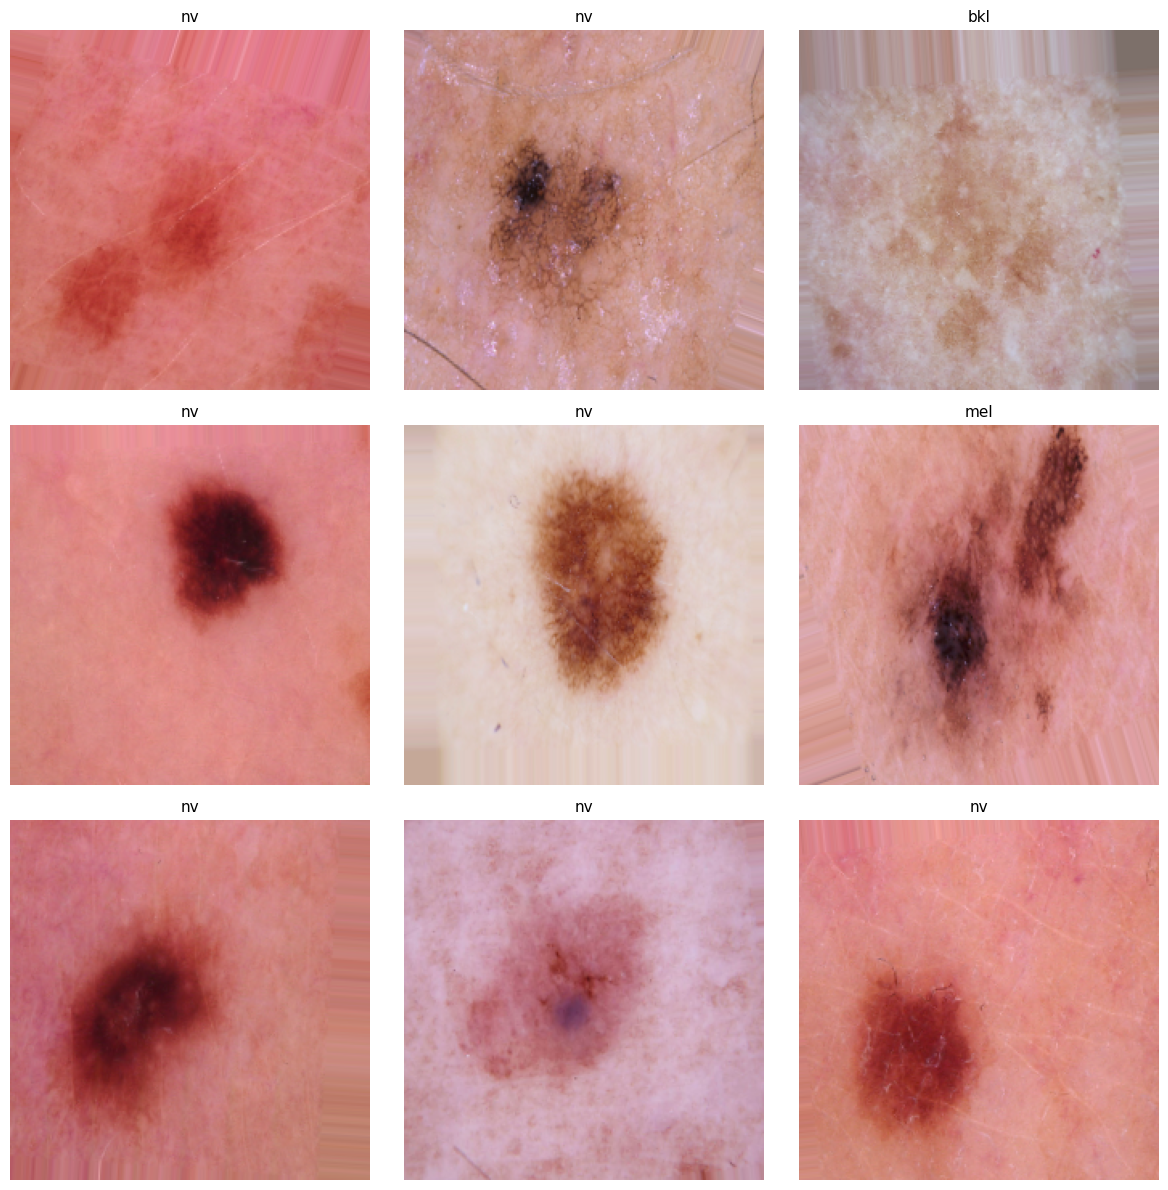

In [39]:
class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])], fontsize=11)

    plt.axis("off")

plt.tight_layout()
plt.show()

**Why do we visualize the augmented images before training?**

**Answer:**
We visualize the augmented images to verify that preprocessing and data augmentation are working correctly. It helps ensure the images are properly loaded, resized, normalized, and transformed without introducing unrealistic distortions that could negatively affect model performance.


# **Analyze the Generators**

In [40]:
print("Training Images :", train_generator.samples)
print("Validation Images :", val_generator.samples)
print("Testing Images :", test_generator.samples)

print()

print("Training Batches :", len(train_generator))
print("Validation Batches :", len(val_generator))
print("Testing Batches :", len(test_generator))

Training Images : 7010
Validation Images : 1502
Testing Images : 1503

Training Batches : 220
Validation Batches : 47
Testing Batches : 47


Why ~220 batches?

7010 / 32 = 219.06

Since the last batch contains the remaining images, TensorFlow creates 220 batches.